In [21]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.1/547.1 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 19.9 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.3 -> 25.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
url = "https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset/data"
df = pd.read_csv('amazon.csv')

# Display the first few rows
print(df.head())

# Basic information
print(df.info())

# Summary statistics
print(df.describe())

   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   

                                            category discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             ₹399   
1  Computers&Accessories|Accessories&Peripherals|...             ₹199   
2  Computers&Accessories|Accessories&Peripherals|...             ₹199   
3  Computers&Accessories|Accessories&Peripherals|...             ₹329   
4  Computers&Accessories|Accessories&Peripherals|...             ₹154   

  actual_price discount_percentage rating rating_count  \
0       ₹1,099                 64%    4.2       24,269   
1         ₹349                 43%  

In [3]:
df.loc[df["rating_count"].isnull(), 'rating_count'] = df["rating_count"].mode()[0]


In [4]:
df["discounted_price"] = df["discounted_price"].apply(lambda x : x.replace("₹",""))
df["actual_price"] =  df["actual_price"].apply(lambda x : x.replace("₹",""))

df["discounted_price"] = df["discounted_price"].apply(lambda x : x.replace(",",""))
df["actual_price"] =  df["actual_price"].apply(lambda x : x.replace(",",""))
df["rating_count"] = df['rating_count'].apply(lambda x : x.replace(",",""))
df["discount_percentage"] = df["discount_percentage"].apply(lambda x : x.replace("%",""))

In [5]:
# Check data types
print(df.dtypes)

# Fill missing values for numeric columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

# Fill missing values for non-numeric columns
non_numeric_columns = df.select_dtypes(include=['object']).columns
df[non_numeric_columns] = df[non_numeric_columns].fillna('Unknown')

# Check for missing values again
print(df.isnull().sum())

product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
review_content         object
img_link               object
product_link           object
dtype: object
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


In [6]:
columns_to_convert = [
    'discounted_price',
    'actual_price',
    'discount_percentage',
    'rating',
    'rating_count'
]

for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
df['category'] = df['category'].str.split("|").str.get(0)
df['product_type'] = df['category'].str.split("|").str.get(-1)
df['total_sales'] = df['actual_price'] * df['rating_count']
df

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,product_type,total_sales
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories,399.0,1099.0,64,4.2,24269,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,Computers&Accessories,26671631.0
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories,199.0,349.0,43,4.0,43994,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,Computers&Accessories,15353906.0
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories,199.0,1899.0,90,3.9,7928,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,Computers&Accessories,15055272.0
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories,329.0,699.0,53,4.2,94363,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,Computers&Accessories,65959737.0
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories,154.0,399.0,61,4.2,16905,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,Computers&Accessories,6745095.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen,379.0,919.0,59,4.0,1090,SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,"AHITFY6AHALOFOHOZEOC6XBP4FEA,AFRABBODZJZQB6Z4U...","Prabha ds,Raghuram bk,Real Deal,Amazon Custome...","R3G3XFHPBFF0E8,R3C0BZCD32EIGW,R2EBVBCN9QPD9R,R...","Received the product without spanner,Excellent...","I received product without spanner,Excellent p...",https://m.media-amazon.com/images/I/41fDdRtjfx...,https://www.amazon.in/Noir-Aqua-Spanner-Purifi...,Home&Kitchen,1001710.0
1461,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen,2280.0,3045.0,25,4.1,4118,"230 Volts, 400 watts, 1 Year","AFG5FM3NEMOL6BNFRV2NK5FNJCHQ,AGEINTRN6Z563RMLH...","Manu Bhai,Naveenpittu,Evatira Sangma,JAGANNADH...","R3DDL2UPKQ2CK9,R2SYYU1OATVIU5,R1VM993161IYRW,R...","ok,everything was good couldn't return bcoz I ...","ok,got everything as mentioned but the measuri...",https://

Numeric Columns: Index(['discounted_price', 'actual_price', 'discount_percentage', 'rating',
       'rating_count', 'total_sales'],
      dtype='object')


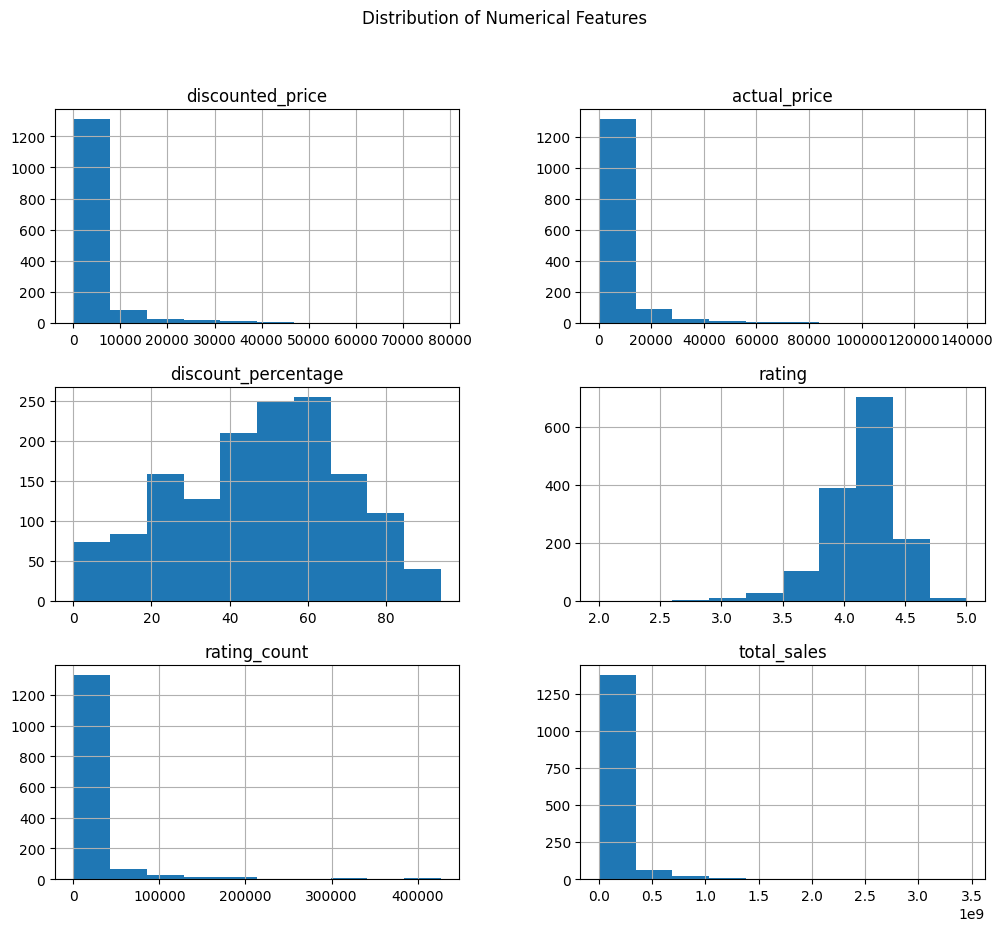

In [8]:
# Select only numeric columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeric Columns:", numeric_columns)

# Plot histograms for numeric columns
if len(numeric_columns) > 0:
    df[numeric_columns].hist(figsize=(12, 10))
    plt.suptitle('Distribution of Numerical Features')
    plt.show()
else:
    print("No numeric columns found for histograms.")

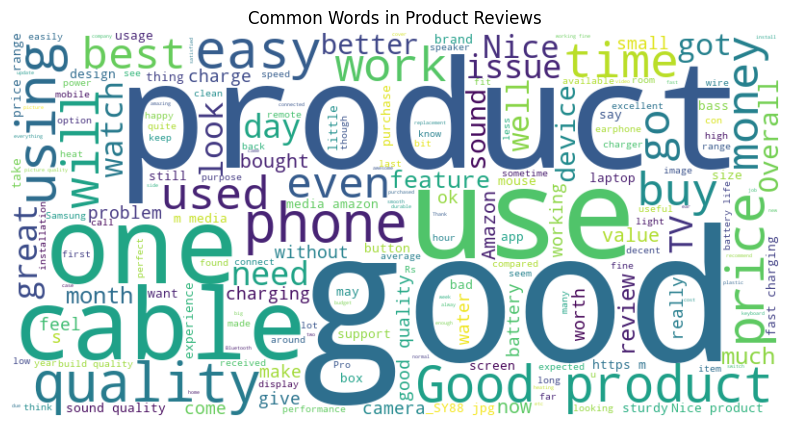

In [9]:
from wordcloud import WordCloud

text = " ".join(df['review_content'].dropna())  # Combine all reviews
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Product Reviews")
plt.show()

/var/folders/td/7y_4cq0535qfps8wc87qt7m80000gn/T/ipykernel_40317/3222002145.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


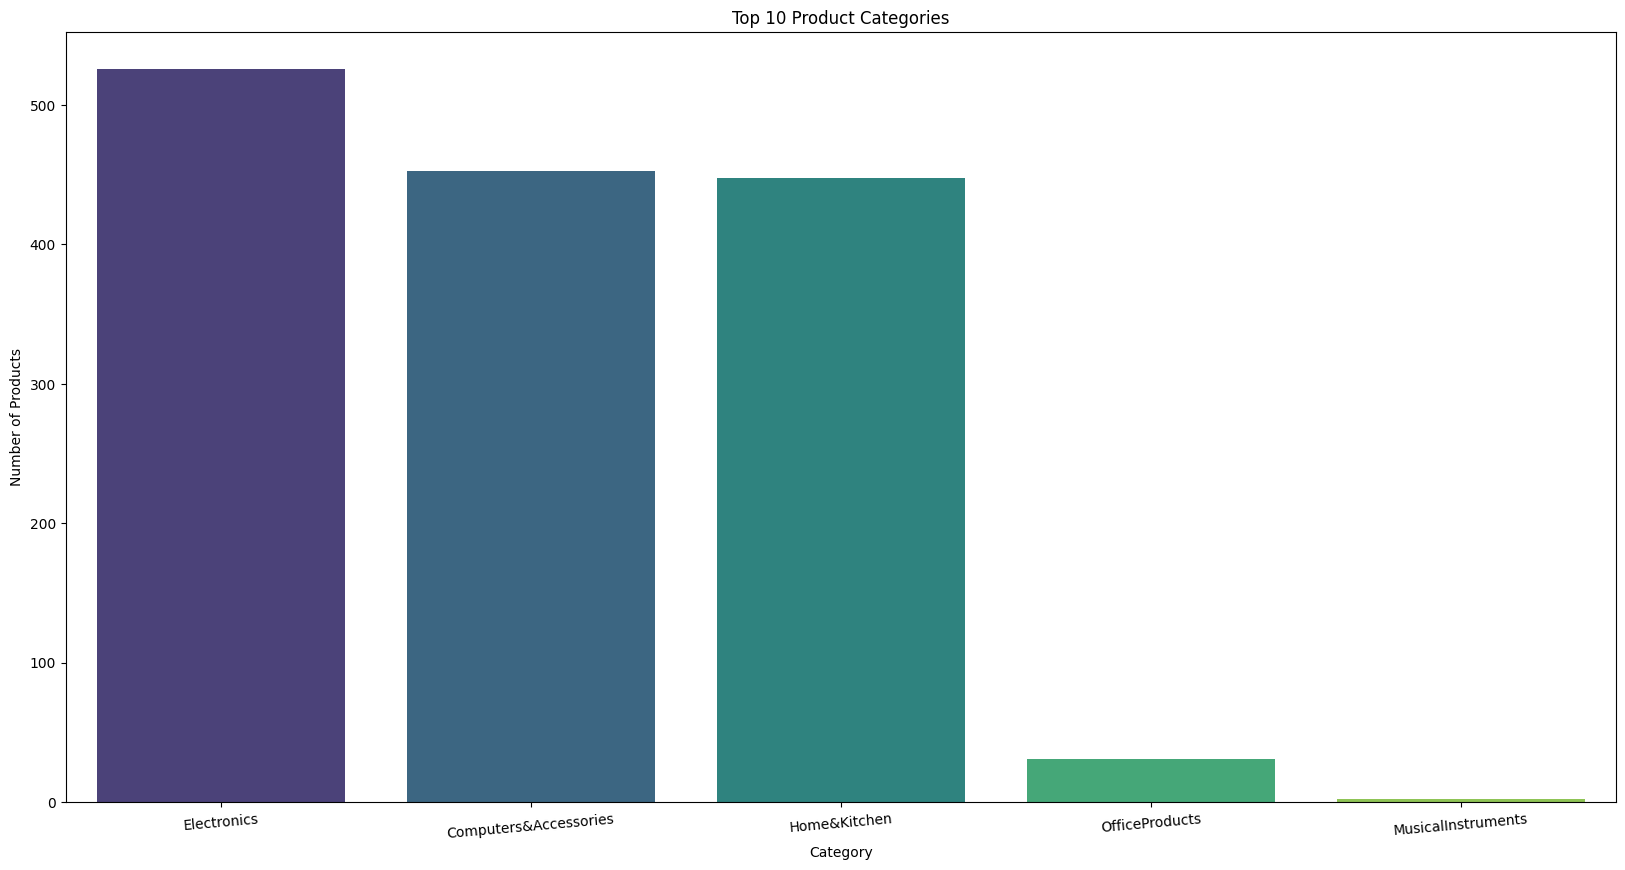

In [10]:
category_counts = df['category'].value_counts().head(5)

plt.figure(figsize=(20, 10))
sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")
plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=5)
plt.show()

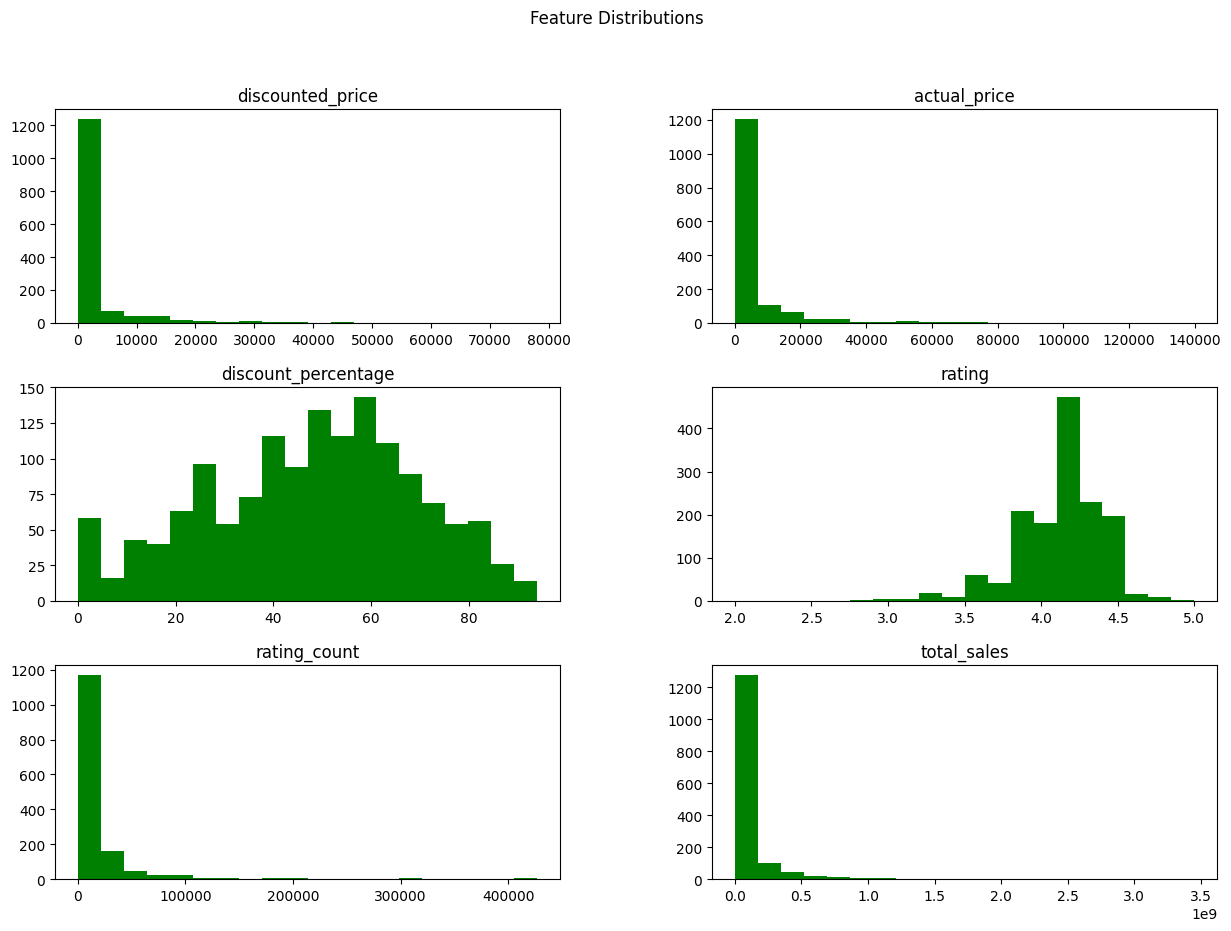

In [11]:
df.hist(bins=20, figsize=(15, 10), grid=False, color = 'green')
plt.suptitle('Feature Distributions')
plt.show()

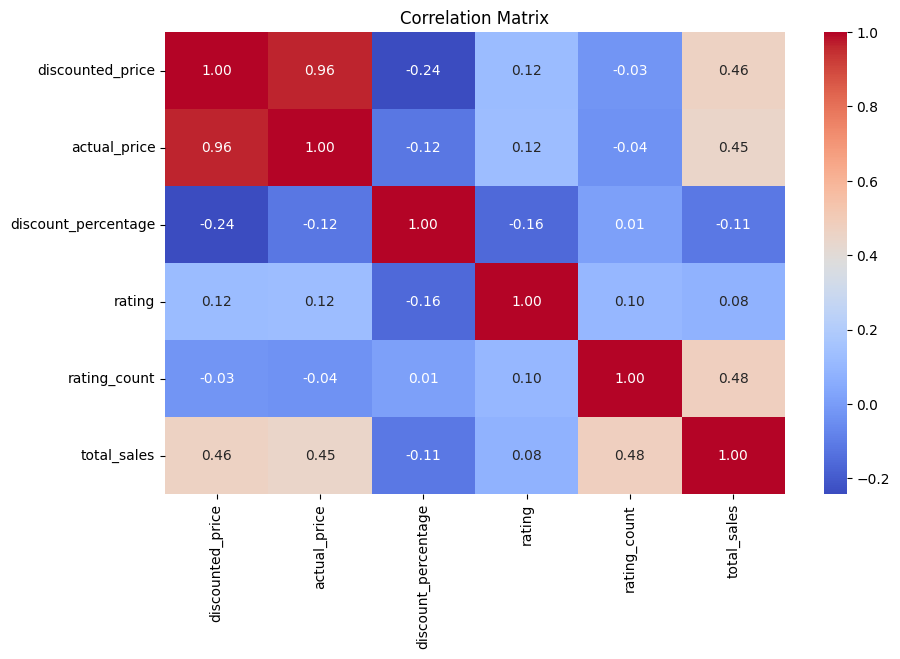

In [12]:
numeric_columns = [
    'discounted_price',
    'actual_price',
    'discount_percentage',
    'rating',
    'rating_count',
    'total_sales'
]
df_corr = df[numeric_columns]
correlation_matrix = df_corr.corr()

# Display the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

/var/folders/td/7y_4cq0535qfps8wc87qt7m80000gn/T/ipykernel_40317/3955817484.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_reviewed, y="product_name", x="rating_count", palette="coolwarm")


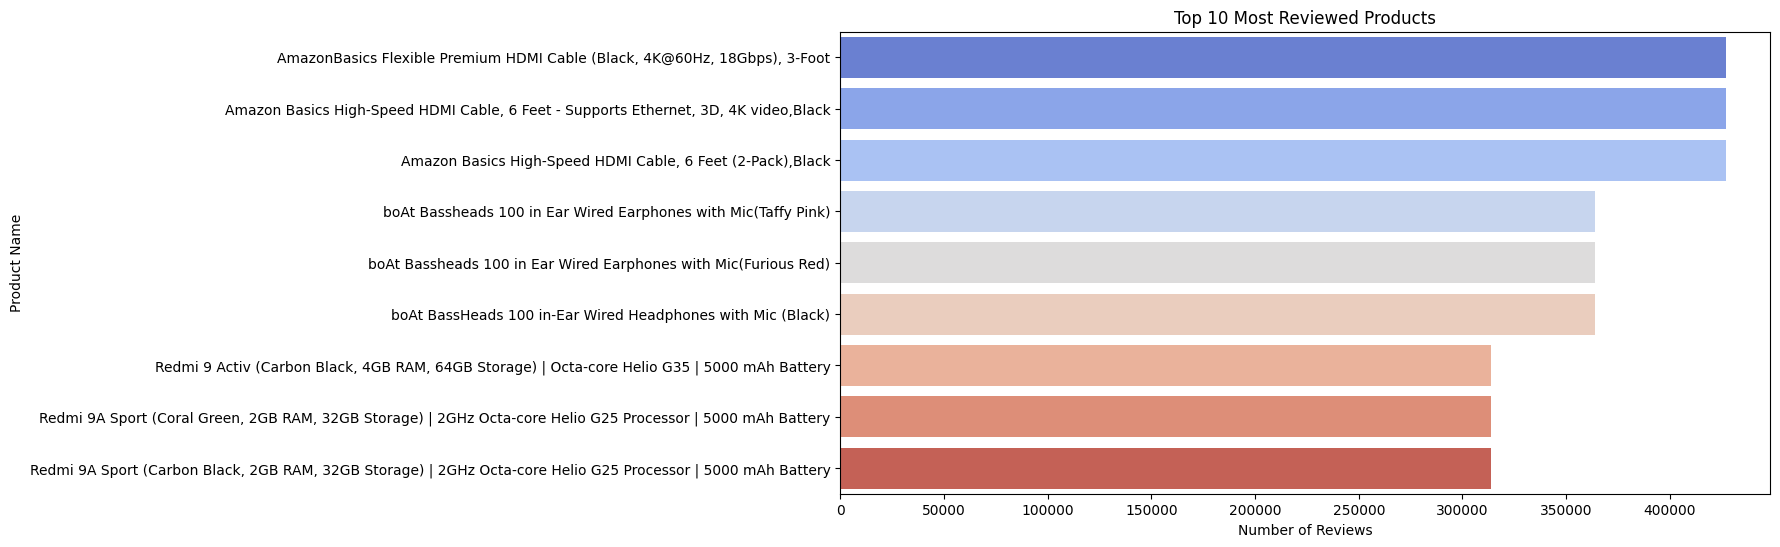

In [13]:
df['rating_count'] = df['rating_count'].replace('[^\d.]', '', regex=True).astype(float)


top_reviewed = df.nlargest(10, "rating_count")

plt.figure(figsize=(12, 6))
sns.barplot(data=top_reviewed, y="product_name", x="rating_count", palette="coolwarm")
plt.title("Top 10 Most Reviewed Products")
plt.xlabel("Number of Reviews")
plt.ylabel("Product Name")
plt.show()

In [14]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link', 'product_type',
       'total_sales'],
      dtype='object')

In [15]:
# Defining features and target
target_column = 'total_sales'
feature_columns = [
    'discounted_price',
    'actual_price',
    'discount_percentage',
    'rating',
    'rating_count',
    'total_sales'
]

X = df[feature_columns]
y = df[target_column]

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [16]:
print(feature_columns)

['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'total_sales']


In [17]:
# Week 6: Model Optimization and Real-Time Testing

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Sample hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}
rf_model = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Best model after tuning
best_model = grid_search.best_estimator_
preds = best_model.predict(X_test)

# Model evaluation
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
print("Tuned Random Forest RMSE:", rmse)


Tuned Random Forest RMSE: 27037830.091153447


In [18]:
print("Mean Sales:", y.mean())
print("Standard Deviation of Sales:", y.std())


Mean Sales: 82829997.20039591
Standard Deviation of Sales: 236950996.1243732


In [19]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, preds)
print("R² Score:", r2)


R² Score: 0.9914970754155321


/Users/yagnesh/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


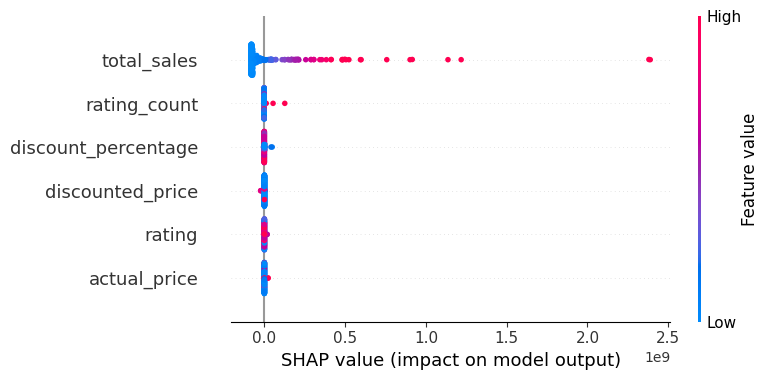

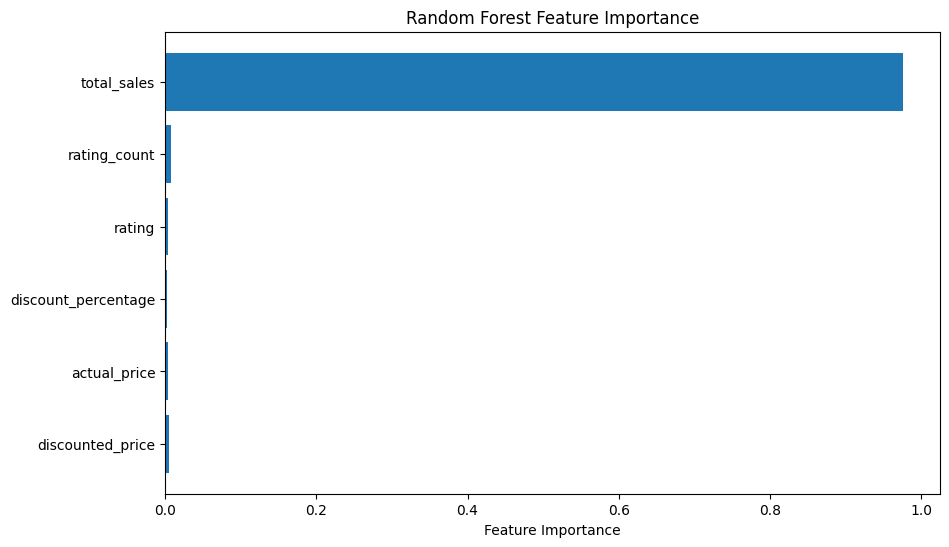

In [22]:
import shap
import matplotlib.pyplot as plt

# Explain model predictions using SHAP
explainer = shap.Explainer(best_model.predict, X_test)
shap_values = explainer(X_test)

# SHAP summary plot
shap.summary_plot(shap_values, X_test)

# Additional feature importance chart
importances = best_model.feature_importances_
feature_names = X_test.columns
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()


## Model Improvements and Sentiment Analysis

The focus was on refining the Random Forest model through hyperparameter tuning, conducting advanced evaluations, and beginning sentiment analysis on product reviews using NLP techniques.


### Final Random Forest Model Evaluation

We used `GridSearchCV` to tune hyperparameters for our Random Forest Regressor. The best model was chosen based on 5-fold cross-validation using the negative mean squared error as a scoring metric.


In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Assuming X_train, y_train, X_test, y_test are defined
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"RMSE: {rmse}")
print(f"R² Score: {r2}")


Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
RMSE: 27742677.731634334
R² Score: 0.99104797240926


### Feature Importance

Below is a bar plot of the most important features that influenced sales prediction.


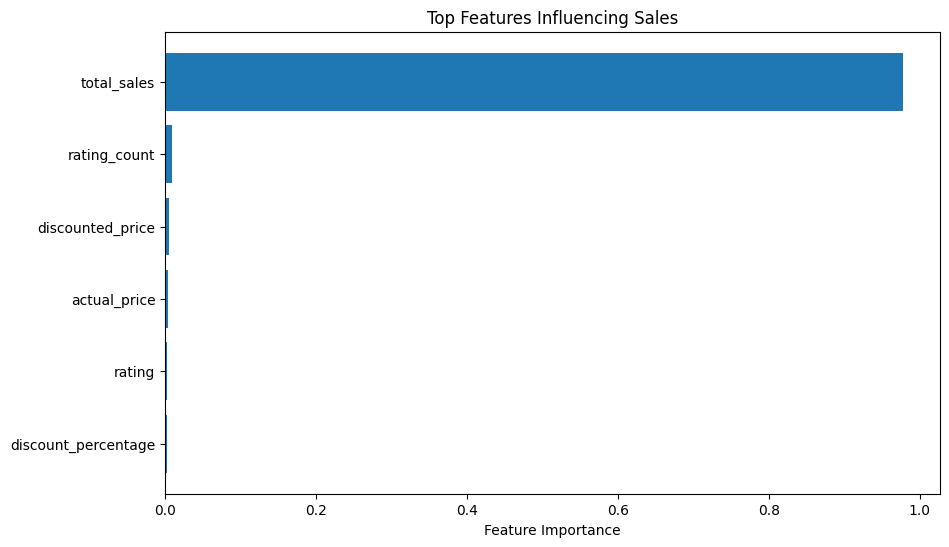

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

importances = best_rf.feature_importances_
features = X_train.columns
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Top Features Influencing Sales')
plt.gca().invert_yaxis()
plt.show()


### Sentiment Analysis on Reviews

We performed basic sentiment analysis using the `TextBlob` library to extract sentiment polarity from product reviews and merged the results back into the main dataset.


In [26]:
!pip install textblob

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 kB 4.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3 -> 25.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [28]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,product_type,total_sales
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories,399.0,1099.0,64,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,Computers&Accessories,26671631.0
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories,199.0,349.0,43,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,Computers&Accessories,15353906.0
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories,199.0,1899.0,90,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,Computers&Accessories,15055272.0
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories,329.0,699.0,53,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,Computers&Accessories,65959737.0
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories,154.0,399.0,61,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,Computers&Accessories,6745095.0


In [33]:
from textblob import TextBlob

# Function to compute sentiment polarity and label
def get_sentiment_label(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0.1:
        label = 'Positive'
    elif polarity < -0.1:
        label = 'Negative'
    else:
        label = 'Neutral'
    return polarity, label

# Apply sentiment analysis
df[['review_sentiment', 'sentiment_label']] = df['review_content'].apply(
    lambda x: pd.Series(get_sentiment_label(x))
)

# Show sample output
df[['product_name', 'review_content', 'review_sentiment', 'sentiment_label']].head()


,product_name,review_content,review_sentiment,sentiment_label
0,Wayona Nylon Braided USB to Lightning Fast Cha...,Looks durable Charging is fine tooNo complains...,0.481944,Positive
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,I ordered this cable to connect my phone to An...,0.274318,Positive
2,Sounce Fast Phone Charging Cable & Data Sync U...,"Not quite durable and sturdy,https://m.media-a...",0.600000,Positive
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,"Good product,long wire,Charges good,Nice,I bou...",0.240370,Positive
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,"Bought this instead of original apple, does th...",0.262740,Positive


## Finalization and Tableau Integration

- Cleaning and exporting the final dataset
- Describing the types of Tableau visualizations used: bar charts, scatter plots (actual vs predicted), category-wise sentiment heatmaps


In [34]:
# Export final dataset for Tableau
df.to_csv("amazon_final_export.csv", index=False)
print("Exported cleaned dataset for Tableau as 'amazon_final_export.csv'")


Exported cleaned dataset for Tableau as 'amazon_final_export.csv'
